
# 05 Rasterio: Working With Real Satellite Imagery

This is the bridge notebook between the two curricula: satellite imagery is **raster** data (a grid of
pixel values), but you still need your **vector** parcel polygons from the GeoPandas curriculum to do
anything useful with it like clipping an image down to just the area of one specific parcel. Rasterio
is what makes both sides of that talk to each other.

## What makes a raster "geospatial"

An ordinary photo is just a grid of pixel values with no inherent location. A **georeferenced** raster
(like a satellite image) adds two things: a **coordinate reference system** (exactly like the CRS concept
from notebook 03 of the GeoPandas curriculum) and a **geotransform** a small set of numbers that map
"pixel row/column" to "real-world coordinate." Rasterio is built specifically to handle both.

## Creating a synthetic georeferenced raster

Real satellite imagery would come from a provider like Sentinel Hub. To keep this notebook runnable
without needing licensed imagery or extra API access, we'll build a small synthetic raster by hand the
exact same rasterio functions apply identically to real downloaded imagery.


In [4]:

import os
# Fix for PROJ version conflict: unset PROJ_LIB/GDAL_DATA so rasterio uses its
# own bundled PROJ data instead of PostgreSQL's outdated proj.db (v2 vs required v6+).
os.environ.pop("PROJ_LIB", None)
os.environ.pop("GDAL_DATA", None)

import numpy as np
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt



## Reading it back and inspecting its geospatial properties


CRS:       EPSG:4326
Transform: | 0.00, 0.00, 9.20|
| 0.00,-0.00, 4.20|
| 0.00, 0.00, 1.00|
Bounds:    BoundingBox(left=9.2, bottom=4.1000000000000005, right=9.299999999999999, top=4.2)
Bands:     3
Shape:     (100, 100)


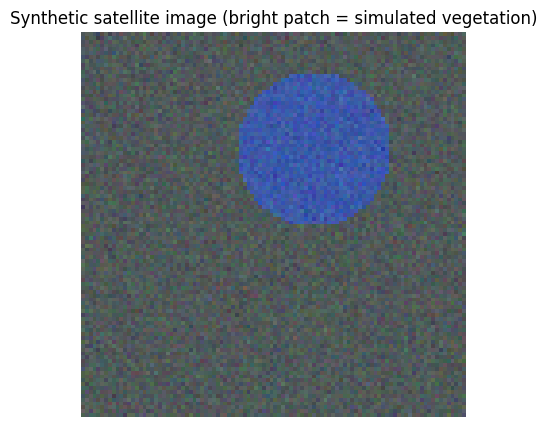

In [5]:

with rasterio.open("./data/synthetic_satellite.tif") as src:
    print("CRS:      ", src.crs)
    print("Transform:", src.transform)
    print("Bounds:   ", src.bounds)
    print("Bands:    ", src.count)
    print("Shape:    ", src.shape)

    data = src.read()  # shape: (bands, height, width)

# For display, build a "true color-ish" RGB composite from our Red/Green/NIR bands
# (using NIR in place of blue just for a visually distinct synthetic preview)
rgb_preview = np.stack([data[0], data[1], data[2]], axis=-1)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_preview)
plt.title("Synthetic satellite image (bright patch = simulated vegetation)")
plt.axis("off")
plt.show()



## Converting between pixel coordinates and real-world coordinates

This is the geotransform doing its actual job going from "row 30, column 60" to a real longitude and
latitude, and back.


In [6]:

with rasterio.open("./data/synthetic_satellite.tif") as src:
    # Pixel (row, col) -> real-world (lon, lat)
    lon, lat = src.xy(30, 60)
    print(f"Pixel (row=30, col=60) corresponds to real-world coordinates: ({lon:.4f}, {lat:.4f})")

    # The reverse: real-world coordinates -> pixel (row, col)
    row, col = src.index(9.26, 4.17)
    print(f"Real-world (9.26, 4.17) corresponds to pixel: (row={row}, col={col})")


Pixel (row=30, col=60) corresponds to real-world coordinates: (9.2605, 4.1695)
Real-world (9.26, 4.17) corresponds to pixel: (row=30, col=60)



## Clipping a raster to a parcel boundary the real bridge back to GeoPandas

This is the actual workflow for verifying land use *within a specific parcel*: take the parcel polygon
from your GeoPandas data, and use it to clip out just that region of the satellite image.


Clipped raster shape: (3, 11, 10)


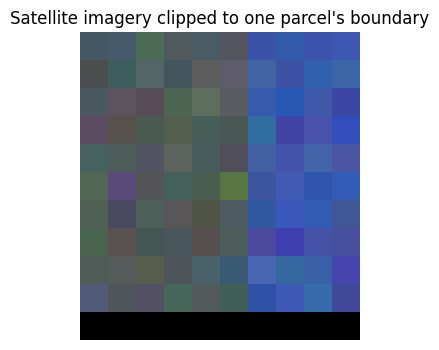

In [7]:

import geopandas as gpd
from shapely.geometry import Polygon, mapping
from rasterio.mask import mask

# A parcel polygon in the same area reusing the exact style of parcel objects from the GeoPandas curriculum
parcel = gpd.GeoDataFrame(
    {"parcel_id": ["PARC-0001"]},
    geometry=[Polygon([(9.235, 4.165), (9.245, 4.165), (9.245, 4.175), (9.235, 4.175)])],
    crs="EPSG:4326",
)

with rasterio.open("./data/synthetic_satellite.tif") as src:
    # rasterio.mask needs geometries in GeoJSON-like dict form shapely.geometry.mapping() does that conversion
    geometry_for_masking = [mapping(geom) for geom in parcel.geometry]
    clipped_data, clipped_transform = mask(src, geometry_for_masking, crop=True)

print("Clipped raster shape:", clipped_data.shape)

clipped_rgb = np.stack([clipped_data[0], clipped_data[1], clipped_data[2]], axis=-1)
plt.figure(figsize=(4, 4))
plt.imshow(clipped_rgb)
plt.title("Satellite imagery clipped to one parcel's boundary")
plt.axis("off")
plt.show()



This clipped output is exactly what a real "verify this parcel's land use" feature would show a reviewer
— the imagery cropped to just the relevant area, computed directly from the same parcel geometry object
your duplicate-sale detection engine (from the GeoPandas capstone) already uses.

## A simple vegetation index a realistic remote-sensing calculation

Real satellite land-cover analysis often computes an index like **NDVI** (Normalized Difference
Vegetation Index), which combines the Red and Near-Infrared bands: `(NIR - Red) / (NIR + Red)`.
Healthy vegetation has high NIR reflectance and lower Red reflectance, producing a high NDVI value
useful for distinguishing vegetated land from built-up or bare land at a glance.


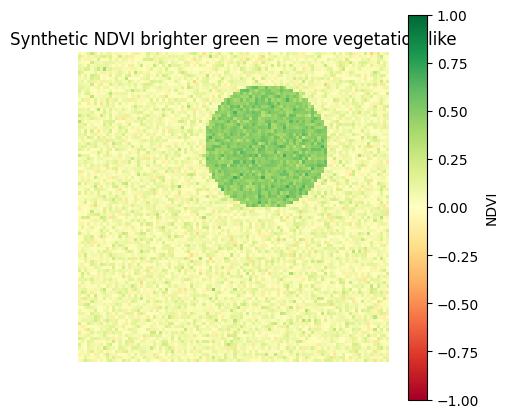

Mean NDVI in the vegetated patch: 0.478
Mean NDVI elsewhere: 0.059


In [8]:

with rasterio.open("./data/synthetic_satellite.tif") as src:
    data = src.read().astype(np.float32)

red_band, nir_band = data[0], data[2]
ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-6)  # small epsilon avoids division by zero

plt.figure(figsize=(5, 5))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("Synthetic NDVI brighter green = more vegetation-like")
plt.axis("off")
plt.show()

print(f"Mean NDVI in the vegetated patch: {ndvi[vegetation_mask].mean():.3f}")
print(f"Mean NDVI elsewhere: {ndvi[~vegetation_mask].mean():.3f}")



## Exercises

### Exercise 1
Compute the mean NDVI specifically within the clipped parcel from earlier, and use it to make a simple
call: is this parcel more consistent with "vegetated/undeveloped land" or "built-up/bare land"? (Hint:
reuse the `clipped_data` array from the clipping cell above apply the same NDVI formula to its Red and
NIR bands.)


In [6]:
# Your code here


#### Solution

In [9]:

clipped_red = clipped_data[0].astype(np.float32)
clipped_nir = clipped_data[2].astype(np.float32)
clipped_ndvi = (clipped_nir - clipped_red) / (clipped_nir + clipped_red + 1e-6)

mean_ndvi = clipped_ndvi.mean()
print(f"Mean NDVI within this parcel: {mean_ndvi:.3f}")
verdict = "vegetated/undeveloped" if mean_ndvi > 0.15 else "built-up/bare"
print(f"Simple verdict: this parcel looks more consistent with {verdict} land.")


Mean NDVI within this parcel: 0.212
Simple verdict: this parcel looks more consistent with vegetated/undeveloped land.



### Exercise 2
Real Sentinel-2 imagery is usually delivered in a projected CRS (often UTM), not `EPSG:4326`. Write the
code to reproject the synthetic raster to `EPSG:32632` (the same UTM zone used throughout the GeoPandas
curriculum for Douala/Buea) using `rasterio.warp.reproject` and `calculate_default_transform`. This
matters for the same reason it mattered in notebook 03 of the GeoPandas curriculum: any real-world pixel
size/area calculation needs a projected CRS to be meaningful.


In [8]:
# Your code here


#### Solution

In [10]:

from rasterio.warp import calculate_default_transform, reproject, Resampling

with rasterio.open("./data/synthetic_satellite.tif") as src:
    dst_crs = "EPSG:32632"
    transform_new, width_new, height_new = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({"crs": dst_crs, "transform": transform_new, "width": width_new, "height": height_new})

    with rasterio.open("./data/synthetic_satellite_utm.tif", "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=transform_new, dst_crs=dst_crs,
                resampling=Resampling.nearest,
            )

with rasterio.open("./data/synthetic_satellite_utm.tif") as reprojected:
    print("Reprojected CRS:", reprojected.crs)
    print("Pixel size in meters (x, y):", reprojected.transform[0], -reprojected.transform[4])


Reprojected CRS: EPSG:32632
Pixel size in meters (x, y): 110.76179362869958 110.76179362869958



## What's next

You can now read, clip, and analyze georeferenced imagery, and connect it to your existing parcel
polygons. The last CV-tagged feature is **land monitoring** comparing imagery of the same area *over
time* to flag encroachment or unauthorized construction. `06_change_detection.ipynb` covers that.
